In [ ]:
#Installing all the nessecery librarys
!pip install pandas numpy matplotlib scipy seaborn
import pandas as pd
import seaborn as sn
import numpy as np
from scipy import stats
print("all libraries loaded successfully")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


all libraries loaded successfully


In [ ]:
#Assigning the csv file to a dataframe
co2_raw = pd.read_csv("C:/Users/turky/Downloadsdddw/co2_mm_gl.csv", comment='#')
display(co2_raw)

,year,month,decimal,average,average_unc,trend,trend_unc
0,1979,1,1979.042,336.56,0.11,335.92,0.09
1,1979,2,1979.125,337.29,0.09,336.26,0.09
2,1979,3,1979.208,337.88,0.11,336.51,0.09
3,1979,4,1979.292,338.32,0.13,336.72,0.10
4,1979,5,1979.375,338.26,0.04,336.71,0.10
...,...,...,...,...,...,...,...
563,2025,12,2025.958,427.32,0.10,426.60,0.06
564,2026,1,2026.042,428.03,0.10,426.88,0.06
565,2026,2,2026.125,428.49,0.10,427.09,0.06
566,2026,3,2026.208,428.43,0.10,426.90,0.06


In [ ]:
#Making a new cloumn with date in a year-month-day format to better graph the data
co2_raw['date'] = pd.to_datetime({'year': co2_raw['year'], 'month': co2_raw['month'], 'day': 1})
display(co2_raw)

,year,month,decimal,average,average_unc,trend,trend_unc,date
0,1979,1,1979.042,336.56,0.11,335.92,0.09,1979-01-01
1,1979,2,1979.125,337.29,0.09,336.26,0.09,1979-02-01
2,1979,3,1979.208,337.88,0.11,336.51,0.09,1979-03-01
3,1979,4,1979.292,338.32,0.13,336.72,0.10,1979-04-01
4,1979,5,1979.375,338.26,0.04,336.71,0.10,1979-05-01
...,...,...,...,...,...,...,...,...
563,2025,12,2025.958,427.32,0.10,426.60,0.06,2025-12-01
564,2026,1,2026.042,428.03,0.10,426.88,0.06,2026-01-01
565,2026,2,2026.125,428.49,0.10,427.09,0.06,2026-02-01
566,2026,3,2026.208,428.43,0.10,426.90,0.06,2026-03-01


In [ ]:
#Checking the data statistic 
co2_raw.describe() 

,year,month,decimal,average,average_unc,trend,trend_unc,date
count,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568
mean,2002.169014,6.471831,2002.666667,376.304736,0.104595,376.294384,0.064894,2002-08-16 11:04:13.521126
min,1979.000000,1.000000,1979.042000,334.360000,0.030000,335.920000,0.030000,1979-01-01 00:00:00
25%,1990.000000,3.000000,1990.854250,354.432500,0.080000,354.675000,0.050000,1990-10-24 06:00:00
50%,2002.000000,6.000000,2002.666500,373.010000,0.100000,373.090000,0.060000,2002-08-16 12:00:00
75%,2014.000000,9.000000,2014.479000,397.382500,0.120000,397.232500,0.080000,2014-06-08 12:00:00
max,2026.000000,12.000000,2026.292000,428.550000,0.260000,427.090000,0.120000,2026-04-01 00:00:00
std,13.677037,3.460421,13.675979,26.109702,0.030909,26.064033,0.017497,NaN


Text(0, 0.5, 'CO2 Average (ppm)')

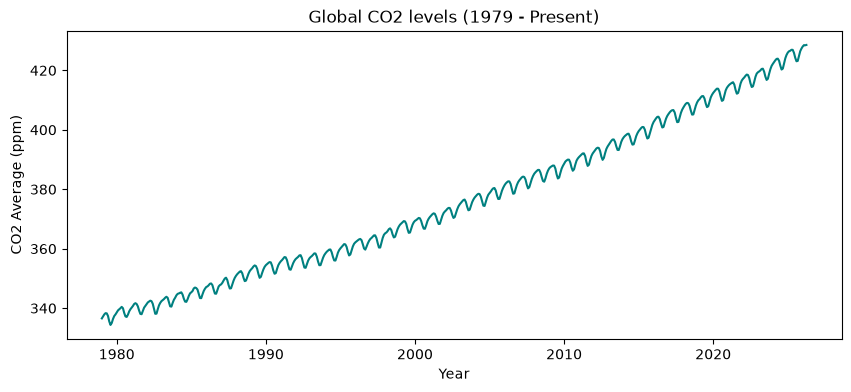

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
sn.lineplot(data=co2_raw, x='date', y='average',
           color='teal')
plt.title("Global CO2 levels (1979 - Present)")
plt.xlabel("Year")
plt.ylabel("CO2 Average (ppm)")

In [ ]:
#A calculation to offset the human emmision from the average biomass co2 levels
co2_raw['seasonal_cycle'] = co2_raw['average'] - co2_raw['trend']
co2_raw['decade'] = (co2_raw['year']// 10) * 10

In [19]:
display(co2_raw)

,year,month,decimal,average,average_unc,trend,trend_unc,date,seasonal_cycle,decade
0,1979,1,1979.042,336.56,0.11,335.92,0.09,1979-01-01,0.64,1970
1,1979,2,1979.125,337.29,0.09,336.26,0.09,1979-02-01,1.03,1970
2,1979,3,1979.208,337.88,0.11,336.51,0.09,1979-03-01,1.37,1970
3,1979,4,1979.292,338.32,0.13,336.72,0.10,1979-04-01,1.60,1970
4,1979,5,1979.375,338.26,0.04,336.71,0.10,1979-05-01,1.55,1970
...,...,...,...,...,...,...,...,...,...,...
563,2025,12,2025.958,427.32,0.10,426.60,0.06,2025-12-01,0.72,2020
564,2026,1,2026.042,428.03,0.10,426.88,0.06,2026-01-01,1.15,2020
565,2026,2,2026.125,428.49,0.10,427.09,0.06,2026-02-01,1.40,2020
566,2026,3,2026.208,428.43,0.10,426.90,0.06,2026-03-01,1.53,2020


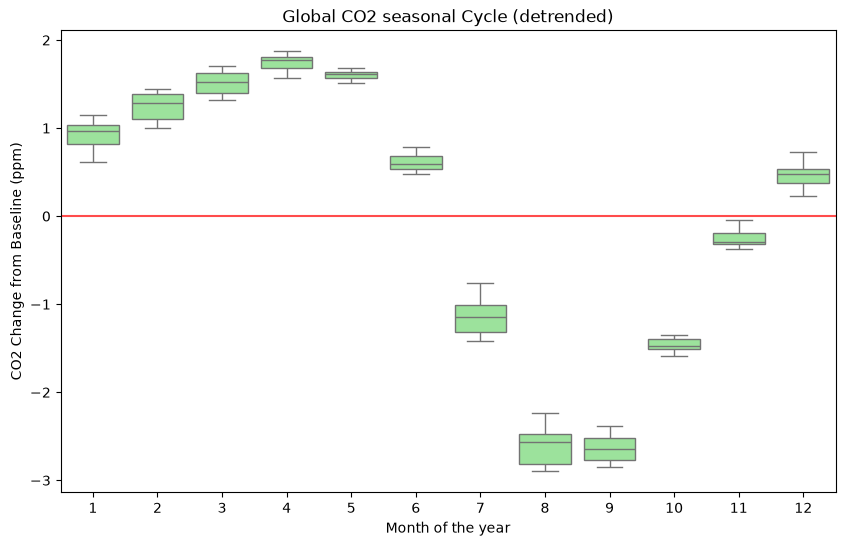

In [29]:
#trying to see at what month do the CO2 concentration dips
plt.figure(figsize=(10, 6))
sn.boxplot(data=co2_raw, x='month', y='seasonal_cycle', color='lightgreen')
plt.title("Global CO2 seasonal Cycle (detrended)")
plt.xlabel("Month of the year")
plt.ylabel("CO2 Change from Baseline (ppm)")

plt.axhline(0, color='red', linestyle='-', alpha=0.7)


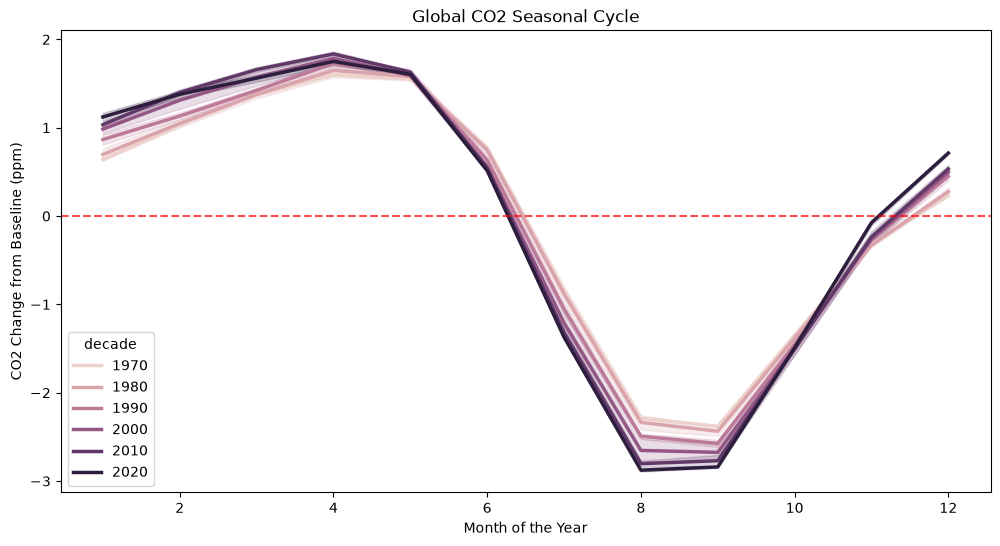

In [30]:
#smae point diffrent graph
plt.figure(figsize=(12, 6))
sn.lineplot(data=co2_raw, x='month', y='seasonal_cycle', hue='decade',
            color='seagreen', errorbar='sd', linewidth=2.5)
plt.title("Global CO2 Seasonal Cycle")
plt.xlabel("Month of the Year")
plt.ylabel("CO2 Change from Baseline (ppm)")

plt.axhline(0, color='red', linestyle='--', alpha=0.7)

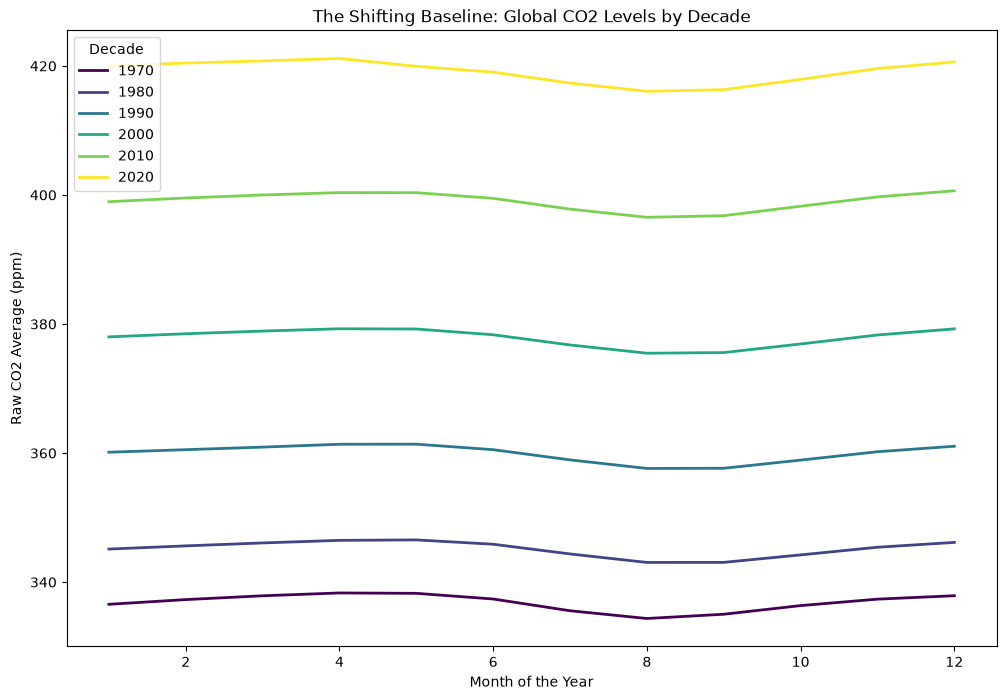

In [37]:
plt.figure(figsize=(12, 8))
sn.lineplot(data=co2_raw, x='month', y='average', hue='decade', 
             palette='viridis', linewidth=2, errorbar=None)

plt.title("The Shifting Baseline: Global CO2 Levels by Decade")
plt.xlabel("Month of the Year")
plt.ylabel("Raw CO2 Average (ppm)")

# Move the legend so it doesn't block the data
plt.legend(title='Decade', loc='upper left')

plt.show()

In [39]:
co2_yearly = co2_raw.groupby('year')['average'].mean().reset_index()
co2_yearly['yoy_growth'] = co2_yearly['average'].diff()
display(co2_yearly.tail())

,year,average,yoy_growth
43,2022,417.084167,2.381667
44,2023,419.352500,2.268333
45,2024,422.789167,3.436667
46,2025,425.643333,2.854167
47,2026,428.375000,2.731667


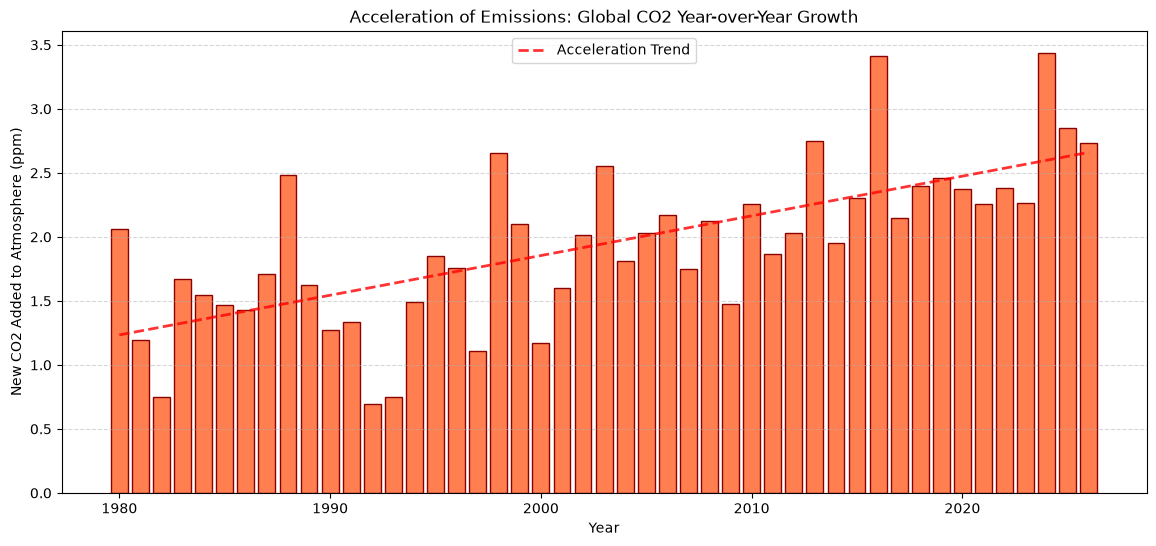

In [49]:
####a bit of learning curve for me
#a Graph in which we utlized the poly function to make a polynomial 1-dimensional (np.poly1d) of a line accross the 'years' values we have by calculating the mathmatical trajectory of the data.
plt.figure(figsize=(14, 6))

plt.bar(co2_yearly['year'], co2_yearly['yoy_growth'], color='coral', edgecolor='darkred')

valid_data = co2_yearly.dropna()
z = np.polyfit(valid_data['year'], valid_data['yoy_growth'], 1)
p = np.poly1d(z)
plt.plot(valid_data['year'], p(valid_data['year']), "r--", linewidth=2, alpha=0.8, label="Acceleration Trend") #r means red

plt.title("Acceleration of Emissions: Global CO2 Year-over-Year Growth")
plt.xlabel("Year")
plt.ylabel("New CO2 Added to Atmosphere (ppm)")
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)

In [44]:
from scipy.stats import linregress

stats = linregress(valid_data['year'], valid_data['yoy_growth'])

print(f"R-squared: {stats.rvalue**2:.4f}")
print(f"P-value: {stats.pvalue:.4e}")

R-squared: 0.4680
P-value: 1.1521e-07
